

# FDTD 1D: Long Transmission Lines

We will excite the electromagnetic wave with an electric field component in the form of an exponential pulse, which is shifted in time relative to the beginning of the simulation.

The source is defined at the beginning of the transmission line (at index `[0]`) and has the following form:

$$
E_z[0] = \exp \left( -\frac{(t-30)^2}{100} \right) \, [\text{V/m}]
$$

This equation describes a Gaussian pulse where:
- The peak of the pulse occurs at time step `t = 30`.
- The denominator `100` controls the width of the pulse.


In [2]:
import matplotlib.pyplot as plt

def tm_plot(times, r):
    """
    Plot Ez field snapshots at selected time steps.

    Parameters
    ----------
    times : list of int
        Time steps to plot.
    r : ndarray
        2D array of shape (time, nodes) containing Ez values.
    """
    plt.figure(figsize=(10, 6))

    for i, t in enumerate(times):
        plt.subplot(len(times), 1, i + 1)
        plt.plot(r[t, :], "r-")
        plt.ylim(-1.1, 1.1)
        plt.xlim(0, r.shape[1])
        plt.legend([f"t={t}"])
        plt.grid(True)

    plt.tight_layout()
    plt.show()


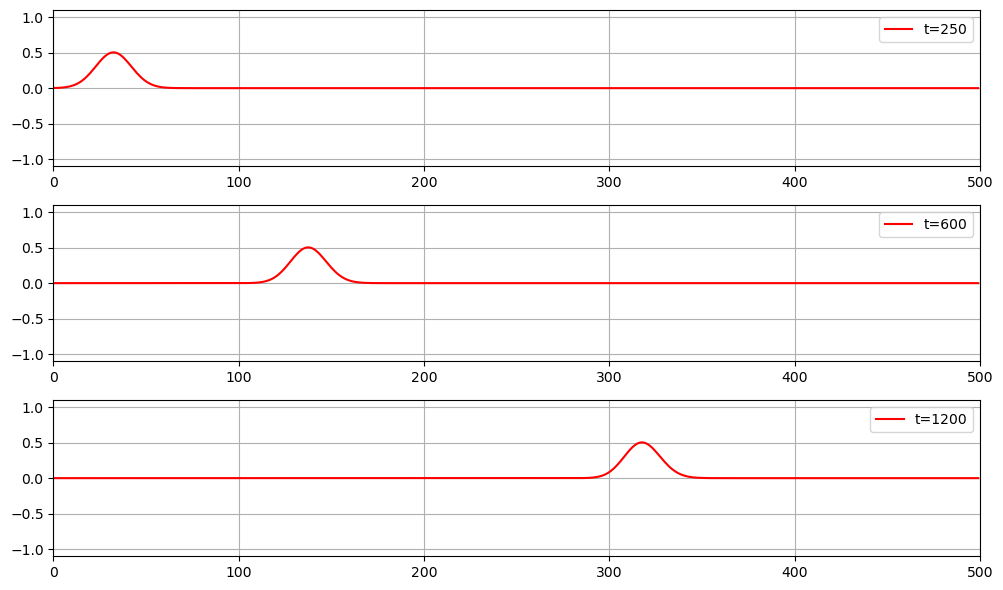

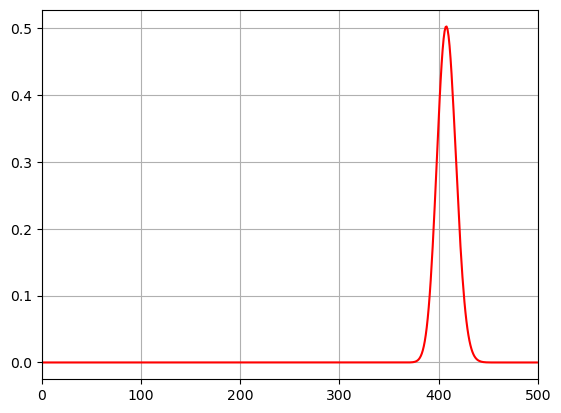

In [3]:

%matplotlib inline
from scipy import *
import matplotlib.pyplot as plt
import numpy as np

nodes = 500
time =2000
V = np.zeros(nodes)
I = np.zeros(nodes)
r = np.zeros((time, nodes))  

dt = 1e-12
dx = 1e-3
Rs = 70
Rz = 170
L = 2.36e-7
C = 4.69e-11

def V0(t):
    #return sin(2*pi*t*0.005)
    return np.exp(-(t*0.7 -100)**2 / 1000.)


for t in range(time):
    
    for m in range(nodes-1):                
        I[m] = I[m] - (dt/(L*dx))*(V[m + 1] - V[m]) 
    
    
    V[0] = (1-2.0*dt/(Rs*C*dx))*V[0] + (2*dt)/(Rs*C*dx)*V0(t) - (2*dt)/(C*dx)*I[0]
    #print(V[0])
    
    for m in range(1,nodes-1):                       
        V[m] = V[m] - (dt/(C*dx))*(I[m] - I[m - 1])   
        
    V[nodes-1] = (1-2.0*dt/(Rz*C*dx))*V[nodes-1] + (2*dt)/(C*dx)*I[nodes-2]
    
    
        
    r[t,:] += V

tm_plot([250,600, 1200], r)
#wv_plot(time, nodes, r)  

tm=[1500]
dt=r
fig = plt.figure()
ax = fig.add_subplot((len(tm))*100+10+(1+0) ) 
#        
ax.plot(dt[tm[0],:], 'r-', label='t=' + str(tm[0]) )
ax.set_xlim(0,500)
#ax.set_ylim(-1,1)
plt.grid()
plt.show()